## Step 1
Tokenize text <br>
Text → token IDs

In [3]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")

In [4]:
text="She drinks water"

tokens=tokenizer(text)

print(tokens)

{'input_ids': [101, 2016, 8974, 2300, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}


In [5]:
tokenizer.tokenize(text)

['she', 'drinks', 'water']

In [8]:
# let's modify littile bit of embeddings step
Tokens=tokenizer(text,return_tensors='pt',add_special_tokens=False)

# return_tensors='pt' : means return pytorch tensors insted of python lists
# add_special_tokens=False: This prevents adding [CLS],[SEP] so input becomes "She drinks water insted " of "[CLS] She drinks water [SEP]"

print(Tokens)
print(tokenizer.tokenize(text))

{'input_ids': tensor([[2016, 8974, 2300]]), 'token_type_ids': tensor([[0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1]])}
['she', 'drinks', 'water']


## Step2
Convert token IDs to embeddings<br>
IDs → vectors using nn.Embedding

In [11]:
input_ids=Tokens['input_ids']
input_ids

tensor([[2016, 8974, 2300]])

Create a Embedding layer

In [12]:
import torch.nn as nn
vocab_size= tokenizer.vocab_size
hidden_size=8

embedding_layer=nn.Embedding(vocab_size,hidden_size)

In this code we created a matrci of shape => (vocab_size x hidden_size)<br>
Now here Each row = one token vector 

Next pass the input Ids into Embedding Layer 


In [13]:
embeddings=embedding_layer(input_ids)

print(f"Embeddings shape {embeddings.shape}")
print(embeddings)

Embeddings shape torch.Size([1, 3, 8])
tensor([[[-1.0967,  0.5622, -0.4296, -1.5908, -0.0917, -1.1920, -1.3274,
          -3.9628],
         [ 0.0078,  0.3876, -0.6476,  1.6102,  0.0825, -1.5746, -0.1766,
          -0.3980],
         [ 1.4217,  0.4435, -1.4992, -0.9996, -0.6335,  1.5237,  0.0225,
           1.3886]]], grad_fn=<EmbeddingBackward0>)


Embeddings shape torch.Size([1, 3, 8]) 

It says 1 → batch size

3 → number of tokens ("She", "drinks", "water")

8 → embedding dimension



Before:

input_ids = [[2016, 4396, 2300]]

After embedding:

[
  [vector_for_2016],<br>
  [vector_for_4396],<br>
  [vector_for_2300]<br>
]

Each number is now replaced with an 8-dimensional vect

## Step3 

Create Q,K,V


![alternative text](image\QKV.png)


Right now:

Each token has 8 numbers.

Example:

She → [0.2, -0.4, 0.7, ...]
But self-attention needs three different views of each token:

→Query view

→Key view

→Value view

So we pass embeddings through three linear layers.

Linear layer = matrix multiplication.

In [14]:
Wq=nn.Linear(hidden_size,hidden_size)
Wk=nn.Linear(hidden_size,hidden_size)
Wv=nn.Linear(hidden_size,hidden_size)

In [15]:
Q=Wq(embeddings)
K=Wk(embeddings)
V=Wv(embeddings)

In [16]:
print("Q Shape: ",Q.shape)
print("K Shape: ",K.shape)
print("V Shape: ",V.shape)

Q Shape:  torch.Size([1, 3, 8])
K Shape:  torch.Size([1, 3, 8])
V Shape:  torch.Size([1, 3, 8])


Token → Q vector

Token → K vector

Token → V vector

## Step 4

Compute attention Scores(QKt)

In [18]:
# but snice we have batch dimesion we use ,
import torch
import math

scores=torch.matmul(Q,K.transpose(-2,-1))

print("Scores: ",scores.shape)
print("Scores: ",scores)

Scores:  torch.Size([1, 3, 3])
Scores:  tensor([[[ 0.4795,  0.2403,  0.3027],
         [-1.1782,  0.8521,  0.3089],
         [-2.6532, -1.5972, -0.1077]]], grad_fn=<UnsafeViewBackward0>)


![alternative text](image\matrix.png)

## Step 5

now scale the score : √d_k


In [19]:

d_k=hidden_size
scaled_scores=scores/math.sqrt(d_k)

print("Scaled scores shape : ",scaled_scores.shape)
print(scaled_scores)

Scaled scores shape :  torch.Size([1, 3, 3])
tensor([[[ 0.1695,  0.0850,  0.1070],
         [-0.4166,  0.3013,  0.1092],
         [-0.9380, -0.5647, -0.0381]]], grad_fn=<DivBackward0>)


## Step 6

Apply soft max

In [20]:
attention_weights=torch.softmax(scaled_scores,dim=-1)

print("Attnetion weights shape: ",attention_weights.shape)
print(attention_weights)

Attnetion weights shape:  torch.Size([1, 3, 3])
tensor([[[0.3499, 0.3215, 0.3287],
         [0.2109, 0.4323, 0.3568],
         [0.2036, 0.2957, 0.5007]]], grad_fn=<SoftmaxBackward0>)


For each token:

How much attention it gives to She

How much attention it gives to drinks

How much attention it gives to water

## Step 7

Multiply by V

In [21]:
attention_output=torch.matmul(attention_weights,V)
print("Attntion output shape : ",attention_output.shape)
print("Attntion output : ",attention_output)

Attntion output shape :  torch.Size([1, 3, 8])
Attntion output :  tensor([[[ 0.2036,  0.1574,  0.1047,  0.2349,  0.3042,  0.0916, -0.2053,
          -0.9490],
         [ 0.3138,  0.1837, -0.0776,  0.1435,  0.1738, -0.0682, -0.4438,
          -0.8177],
         [ 0.2713,  0.1851, -0.0791,  0.2453,  0.3601, -0.0183, -0.4272,
          -0.9058]]], grad_fn=<UnsafeViewBackward0>)


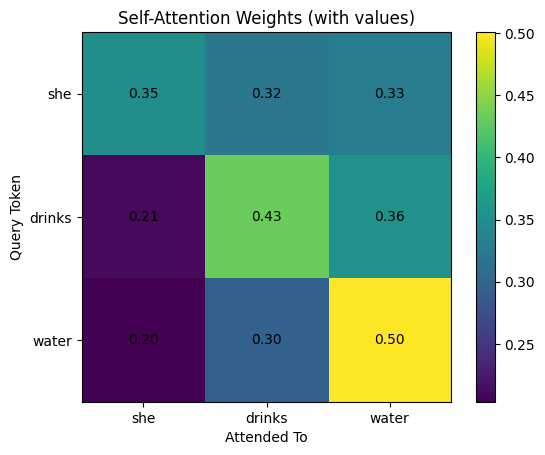

In [25]:
weights = attention_weights[0].detach().numpy()
tokens_list = ["she", "drinks", "water"]

plt.figure()
plt.imshow(weights)

for i in range(weights.shape[0]):
    for j in range(weights.shape[1]):
        plt.text(j, i, f"{weights[i, j]:.2f}",
                 ha="center", va="center")

plt.xticks(range(len(tokens_list)), tokens_list)
plt.yticks(range(len(tokens_list)), tokens_list)
plt.title("Self-Attention Weights (with values)")
plt.xlabel("Attended To")
plt.ylabel("Query Token")
plt.colorbar()
plt.show()